# General notebook

In [32]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


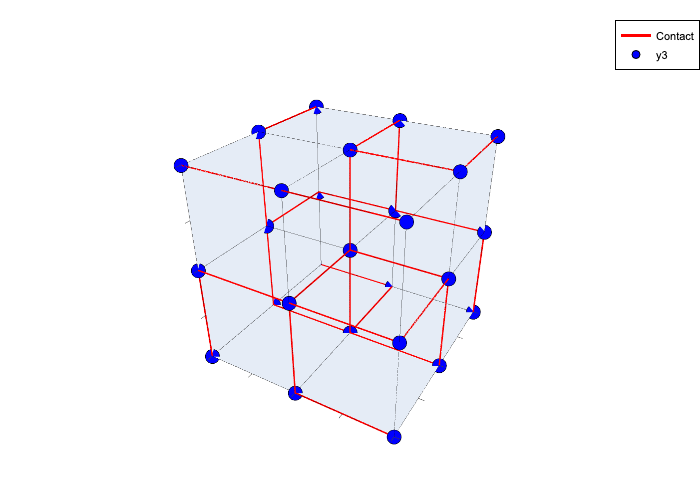

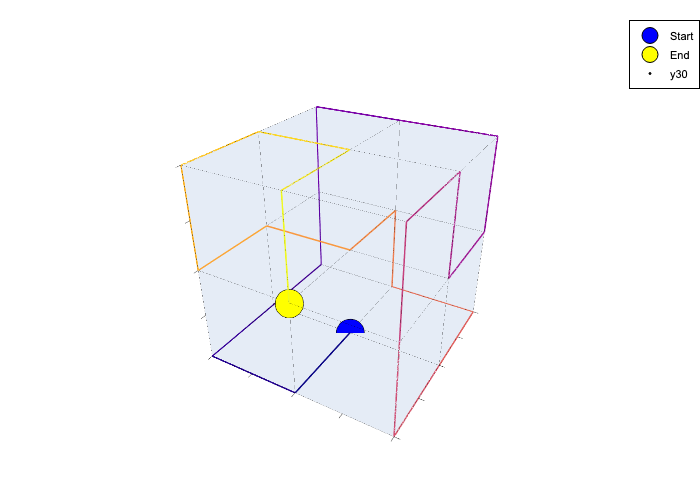

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:12


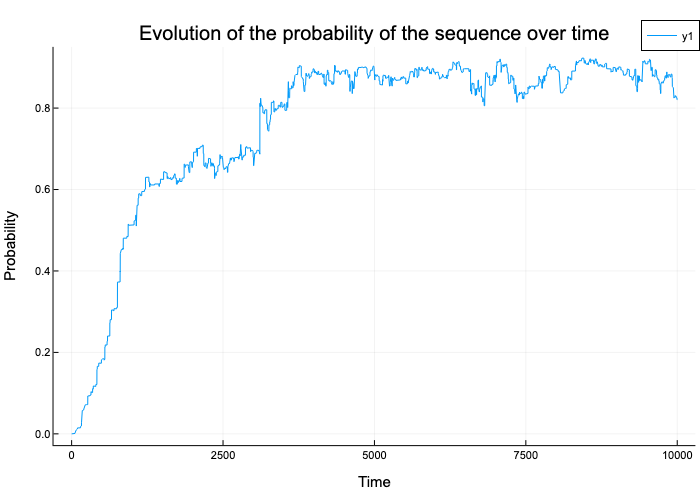

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


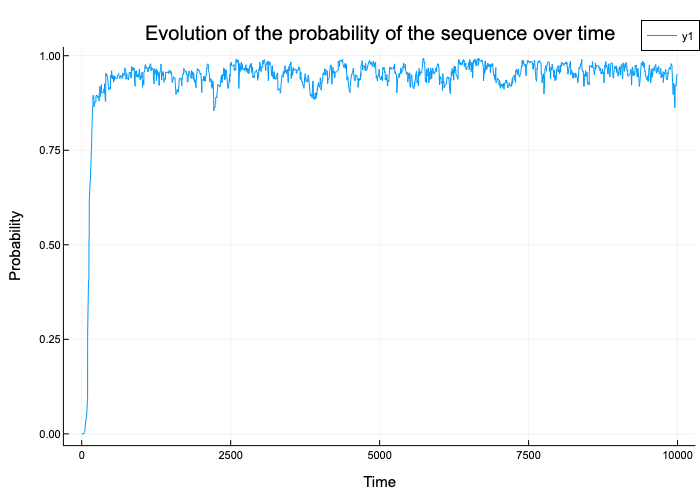

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


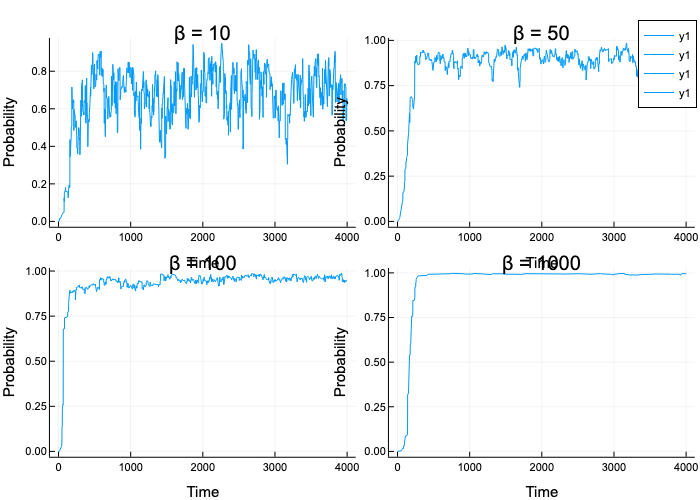

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([3, 17, 19, 15, 2, 18, 19, 7, 4, 11  …  3, 10, 15, 19, 5, 18, 19, …
  10.0   => ([4, 9, 14, 15, 9, 13, 18, 5, 15, 16  …  14, 18, 11, 15, 3, 12, 2, …
  1000.0 => ([7, 15, 3, 19, 19, 15, 15, 15, 15, 16  …  18, 12, 18, 16, 2, 16, 5…
  100.0  => ([3, 11, 3, 16, 5, 14, 14, 6, 6, 9  …  5, 4, 16, 17, 1, 18, 19, 1, …

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:21


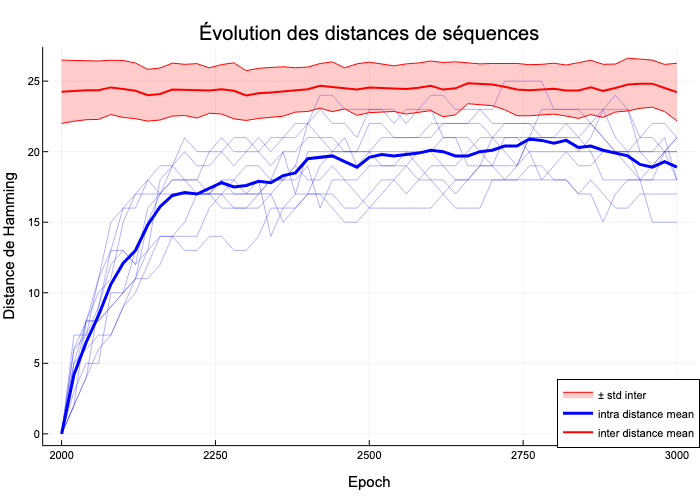

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


structure 1234 : 0.9669333755070466
structure 1578 : 0.003077536979068097
structure 1233 : 0.0023967882092293977
structure 493 : 0.002396788209229372
structure 529 : 0.0022798954689153854
structure 1111 : 0.0018666205342041963
structure 1778 : 0.0018666205342041846
structure 572 : 0.0016066151827483371
structure 1289 : 0.0015282596356798247
structure 1205 : 0.0007218987357993027
structure 4972 : 0.0006532009881840798
structure 1797 : 0.000621344000073642
structure 1785 : 0.0006213440000736358
structure 1204 : 0.0005910406956070055
structure 496 : 0.000483903193814064
structure 561 : 0.0004839031938140593
structure 7762 : 0.00046030295656581066
structure 4977 : 0.00034100081725761715
structure 7760 : 0.0003243700111542397
structure 10313 : 0.0003243700111542346


In [9]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 21
  16 => 23
  20 => 14
  12 => 28
  24 => 26
  8  => 24
  17 => 20
  1  => 37
  23 => 14
  22 => 23
  19 => 25
  6  => 30
  11 => 29
  9  => 19
  14 => 21
  3  => 33
  7  => 19
  25 => 24
  13 => 35
  ⋮  => ⋮

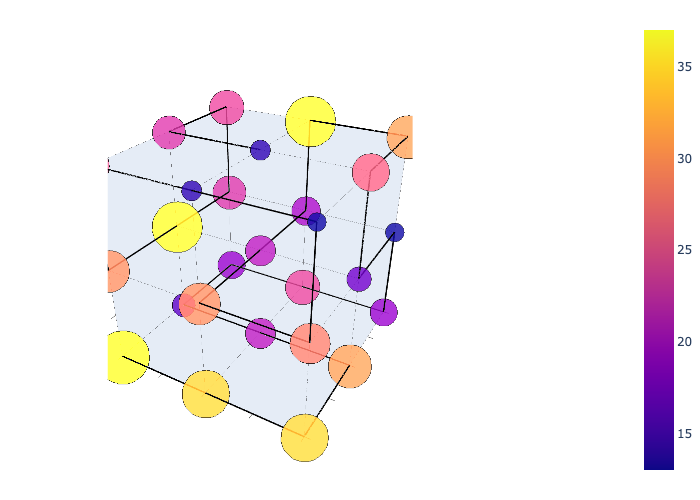

In [10]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[1234], n_mutations_per_position)

## Tree generation

In [ ]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)
newick, seq_dict = create_genealogy(root_seq, 50, 2, target_number, all_ctc_maps)

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : " * join([aa_idx[acid] for acid in seq_dict[name]], " "))
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : GLU GLN ASP ARG LYS GLU MET GLU HIS ASP GLU ARG LEU ARG ARG CYS LYS LYS ARG CYS GLY LEU ASP GLU ILE ASN LYS
N4 : ASN GLU ILE ARG LYS ASP TYR ASP GLU GLU ASP ARG LEU GLY LYS VAL LYS LYS ARG ALA MET LEU ASP GLU LEU GLY ASN
N5 : ASP TRP GLU LYS ARG GLU ASP ASP GLU GLU GLU LYS LEU HIS ARG ILE LYS LYS LYS ILE ALA VAL TRP GLU ILE HIS LYS
N7 : ASN LEU ASP LYS LYS PHE ASP LEU ASP ARG GLU LYS VAL LYS LYS ALA HIS ARG ASP MET GLN ILE THR GLU ILE HIS ARG
N1 : ALA ASN ILE ASN LYS GLU GLN ASP ASN GLU ASP LYS LEU HIS ARG VAL LYS LYS LYS TYR MET PHE ASP GLU ILE PRO LYS
N6 : MET GLU GLU SER ARG TRP ASP GLU GLU THR GLU LYS CYS ARG ARG ILE LYS LYS THR TYR ILE VAL TYR GLU ILE LYS LYS
N2 : GLY PRO GLU ARG LYS GLU GLN ASP ASP GLU GLU ARG ILE HIS ARG VAL LYS LYS ARG TRP VAL LEU ASP GLU ILE THR PRO


In [21]:
simple_print_distance_matrix(seq_dict)

      N3    N4    N5    N7    N1    N6    N2    
N3    0     17    18    22    17    18    14    
N4    17    0     20    23    15    22    15    
N5    18    20    0     20    14    13    16    
N7    22    23    20    0     23    22    22    
N1    17    15    14    23    0     19    14    
N6    18    22    13    22    19    0     20    
N2    14    15    16    22    14    20    0     


In [22]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/Users/marie.gabilly/Documents/master/m1/s2/projet/figures/distance_matrix.svg"

In [23]:
tree


                                        _____________________________________ N3
  _____________________________________|
 |                                     |_____________________________________ N4
_|
 |                                      _____________________________________ N6
 |_____________________________________|
                                       |_____________________________________ N7


In [24]:
result = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result))
    println("$name : " * join([aa_idx[acid] for acid in seq], " "))
end

N1 : ASN GLU ASP ARG LYS GLU ASP GLU GLU ASP GLU ARG LEU ARG ARG ILE LYS LYS ASP MET ILE LEU ASP GLU ILE GLY LYS
N2 : ASN GLU ASP ARG LYS GLU MET GLU GLU ASP GLU ARG LEU ARG ARG VAL LYS LYS ARG ALA MET LEU ASP GLU ILE GLY LYS
N3 : GLU GLN ASP ARG LYS GLU MET GLU HIS ASP GLU ARG LEU ARG ARG CYS LYS LYS ARG CYS GLY LEU ASP GLU ILE ASN LYS
N4 : ASN GLU ILE ARG LYS ASP TYR ASP GLU GLU ASP ARG LEU GLY LYS VAL LYS LYS ARG ALA MET LEU ASP GLU LEU GLY ASN
N5 : ASN GLU ASP SER LYS TRP ASP GLU GLU THR GLU LYS VAL ARG ARG ILE LYS LYS ASP MET ILE ILE THR GLU ILE HIS LYS
N6 : MET GLU GLU SER ARG TRP ASP GLU GLU THR GLU LYS CYS ARG ARG ILE LYS LYS THR TYR ILE VAL TYR GLU ILE LYS LYS
N7 : ASN LEU ASP LYS LYS PHE ASP LEU ASP ARG GLU LYS VAL LYS LYS ALA HIS ARG ASP MET GLN ILE THR GLU ILE HIS ARG


In [17]:
@which root(tree)

root(t::Tree)
     @ TreeTools ~/.julia/packages/TreeTools/nIWnY/src/objects.jl:194

In [18]:
typeof(root)

typeof(root) (singleton type of function root, subtype of Function)

In [30]:
reconstruction_error_hamming(result, seq_dict)

Hamming distance for N3 : 0
Hamming distance for N4 : 0
Hamming distance for N5 : 15
Hamming distance for N7 : 0
Hamming distance for N1 : 17
Hamming distance for N6 : 0
Hamming distance for N2 : 13


6.428571428571429

In [35]:
distance_btw_nodes = 0:10:100
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 2

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


MethodError: MethodError: no method matching plot_reconstruction_error(::Vector{Int64}, ::StepRange{Int64, Int64}, ::Int64, ::Int64, ::Vector{Any}; beta::Int64)
This method does not support all of the given keyword arguments (and may not support any).

Closest candidates are:
  plot_reconstruction_error(::Any, ::Any, ::Any, ::Any, ::Any, !Matched::Any) got unsupported keyword argument "beta"
   @ Main ~/Documents/master/m1/s2/projet/code/tree.jl:184
  plot_reconstruction_error(::Any, ::Any, ::Any, ::Any, ::Any) got unsupported keyword argument "beta"
   @ Main ~/Documents/master/m1/s2/projet/code/tree.jl:184
